# Notebook 2: Behavior Cloning

## 2.0 Preamble

This notebook trains a condition-aware behavior cloning model (DriveNet) on the expert driving data collected in Notebook 1. The model learns to predict steering, throttle, and brake commands from a front-facing camera image, vehicle state, and environmental metadata (weather, town, road type, time of day, traffic density). Training uses a weighted MSE loss that upweights braking 5x to compensate for the natural class imbalance where most frames have brake=0. The final checkpoint (`BC_model_best.pt`) serves as the initialization for PPO fine-tuning in Notebook 3.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Ensure project root is on sys.path so src imports resolve
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.agents import BehaviorCloningAgent
from src.drivenet import DriveNet
from src.drivenet_lidar import LidarDriveNet
from src.drivenet_multicam import MultiCamDriveNet
from src.preprocessing import (crop_and_resize, encode_metadata, normalize_states,
                                CROP_TOP, CROP_BOTTOM, RESIZE_H, RESIZE_W)
from src.training import predict_all

# Plotting defaults
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

# Change this to "multi_cam" or "lidar" to train a different sensor suite.
SENSOR_SUITE = "single_cam"

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print(f"Sensor suite: {SENSOR_SUITE}")


Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Sensor suite: single_cam


## 2.1 Configuration

All hyperparameters and encoding maps for behavior cloning are centralized in `configs/bc.yaml`. Loading them through `load_config()` ensures consistency between this notebook and the `BehaviorCloningAgent`. No training parameter is hardcoded in the notebook itself -- every value comes from the config file.

### 2.1.1 Loading Parameters

We load the BC config and print the key hyperparameters: learning rate, batch size, early stopping patience, and loss weights. The loss weights `[1.0, 1.0, 5.0]` upweight the brake target 5x because the vast majority of frames have brake=0, and without upweighting the model would learn to ignore braking entirely.

In [2]:
cfg = load_config("bc")

print("=== Behavior Cloning Configuration ===")
print(f"  Seed:                {cfg['seed']}")
print(f"  Batch size:          {cfg['batch_size']}")
print(f"  Learning rate:       {cfg['lr']}")
print(f"  Weight decay:        {cfg['weight_decay']}")
print(f"  Max epochs:          {cfg['max_epochs']}")
print(f"  Early stop patience: {cfg['early_stop_patience']}")
print(f"  LR patience:         {cfg['lr_patience']}")
print(f"  LR factor:           {cfg['lr_factor']}")
print(f"  Dropout:             {cfg['dropout']}")
print(f"  Loss weights:        {cfg['loss_weights']}  (steer, throttle, brake)")
print(f"  Test fraction:       {cfg['test_fraction']}")
print(f"  Val fraction:        {cfg['val_fraction']}")
print(f"  Meta dims:           {cfg['meta_dims']}")
print(f"  Model name:          {cfg['model_name']}")

=== Behavior Cloning Configuration ===
  Seed:                42
  Batch size:          128
  Learning rate:       0.0001
  Weight decay:        1e-05
  Max epochs:          200
  Early stop patience: 20
  LR patience:         3
  LR factor:           0.5
  Dropout:             0.3
  Loss weights:        [1.0, 1.0, 5.0]  (steer, throttle, brake)
  Test fraction:       0.15
  Val fraction:        0.1
  Meta dims:           [6, 3, 3, 3, 3]
  Model name:          BC_model


### 2.1.2 Architecture Summary

DriveNet is a 5-layer convolutional network followed by a 4-layer MLP head. The CNN processes 100x200 RGB images and produces a flattened feature vector. This is concatenated with a 3-dimensional vehicle state vector (speed, sin_heading, cos_heading) and learned metadata embeddings, then mapped to 3 action outputs through the MLP. Steering uses tanh activation; throttle and brake use sigmoid.

In [3]:
model = DriveNet(
    dropout=cfg["dropout"],
    state_dim=6,
    action_dim=3,
    meta_dims=cfg["meta_dims"],
)

print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nInput image shape:  (3, {RESIZE_H}, {RESIZE_W})")
print(f"CNN feature dim:    {model._feat_size}")
print(f"State dim:          6  (speed, sin_heading, cos_heading,")
print(f"                        speed_limit_norm, lane_count_norm, is_junction)")
print(f"Backbone output:    {model.backbone_output_dim}  (CNN + state_dim)")

DriveNet(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): GroupNorm(4, 24, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (4): GroupNorm(6, 36, eps=1e-05, affine=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (7): GroupNorm(8, 48, eps=1e-05, affine=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (10): GroupNorm(8, 64, eps=1e-05, affine=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (13): GroupNorm(8, 64, eps=1e-05, affine=True)
    (14): ReLU(inplace=True)
    (15): Flatten(start_dim=1, end_dim=-1)
  )
  (meta_embeddings): ModuleList(
    (0): Embedding(6, 4)
    (1-4): 4 x Embedding(3, 2)
  )
  (head): Sequential(
    (0): Linear(in_features=5778, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3

## 2.2 Data Loading and Preprocessing

Before training, we load all collected `.npz` chunks from every town, crop and resize the images to the model's expected input shape (100x200), and encode the string metadata labels into integer indices. The data is then split into train, validation, and test sets using the fractions specified in the config.

### 2.2.1 Load All Chunks

This cell loads and concatenates all chunk files across every town directory. The loading pattern mirrors what `BehaviorCloningAgent._load_all_chunks()` does internally, so the notebook and the agent always produce identical datasets. After loading, we report the total frame count and the keys available in the data.

In [4]:
suite_data_dir = DATA_DIR / SENSOR_SUITE
chunk_files = sorted(suite_data_dir.rglob("chunk_*.npz"))
print(f"Sensor suite : {SENSOR_SUITE}")
print(f"Data dir     : {suite_data_dir}")
print(f"Found {len(chunk_files)} chunk files")

# Payload key varies by suite
if SENSOR_SUITE == "single_cam":
    payload_key = "images"
elif SENSOR_SUITE == "multi_cam":
    payload_key = "images_multi"
else:  # lidar
    payload_key = "bev"

# Load and preprocess images chunk-by-chunk so full-resolution frames are
# never all in RAM at once (mirrors BehaviorCloningAgent._load_all_chunks()).
image_parts = []
other_parts = {}

for path in chunk_files:
    chunk = np.load(path, allow_pickle=True)
    raw_imgs = chunk[payload_key]

    if SENSOR_SUITE == "single_cam":
        processed = crop_and_resize(raw_imgs)
    elif SENSOR_SUITE == "multi_cam":
        n_f, n_c = raw_imgs.shape[0], raw_imgs.shape[1]
        processed = np.empty((n_f, n_c, RESIZE_H, RESIZE_W, 3), dtype=np.uint8)
        for cam in range(n_c):
            processed[:, cam] = crop_and_resize(raw_imgs[:, cam])
    else:  # lidar — BEV is already at model resolution
        processed = raw_imgs

    image_parts.append(processed)
    for key in chunk.files:
        if key != payload_key:
            other_parts.setdefault(key, []).append(chunk[key])

raw = {"images": np.concatenate(image_parts, axis=0)}
raw.update({k: np.concatenate(v, axis=0) for k, v in other_parts.items()})

# States are kept as raw 5-D here; DrivingDataset normalises them internally
# in the scatter-plot section below.  Do NOT call normalize_states() here —
# it would double-normalise states before DrivingDataset sees them.

print(f"Total frames loaded: {raw['images'].shape[0]:,}")
print(f"Image shape:         {raw['images'].shape[1:]}")
print(f"State shape:         {raw['states'].shape}  (raw 5-D)")
print(f"Keys: {list(raw.keys())}")

Sensor suite : single_cam
Data dir     : C:\Users\joshu\Documents\Projects\CARLA AV\data\single_cam
Found 29 chunk files


Total frames loaded: 65,304
Image shape:         (100, 200, 3)
State shape:         (65304, 5)  (raw 5-D)
Keys: ['images', 'states', 'actions', 'locations', 'tl_states', 'speed_limits', 'weather_preset', 'road_type', 'time_of_day', 'traffic_density', 'style']


### 2.2.2 Dataset Splits

The data is split into train, validation, and test sets using the fractions from the config (test=15%, val=10% of remainder). A fixed random seed ensures reproducibility. The split indices are saved to disk so downstream evaluation can use the exact same test set.

In [5]:
n = raw["images"].shape[0]
rng = np.random.default_rng(cfg["seed"])
idx = rng.permutation(n)

n_test = int(n * cfg["test_fraction"])
n_val = int((n - n_test) * cfg["val_fraction"])
n_train = n - n_test - n_val

print(f"Total frames: {n:,}")
print(f"  Train: {n_train:,}  ({n_train / n * 100:.1f}%)")
print(f"  Val:   {n_val:,}  ({n_val / n * 100:.1f}%)")
print(f"  Test:  {n_test:,}  ({n_test / n * 100:.1f}%)")

Total frames: 65,304
  Train: 49,959  (76.5%)
  Val:   5,550  (8.5%)
  Test:  9,795  (15.0%)


### 2.2.3 Metadata Encoding

String metadata labels (weather preset, town, road type, time of day, traffic density) are mapped to integer codes using the dictionaries defined in the config. These integer codes are used as indices into learned embedding layers inside DriveNet, allowing the model to adapt its behavior based on driving conditions.

In [6]:
print("Weather codes:", cfg["weather_codes"])
print("Road type codes:", cfg["road_type_codes"])
print("TOD codes:    ", cfg["tod_codes"])
print("Traffic codes:", cfg["traffic_codes"])
print("Style codes:  ", cfg["style_codes"])

meta = encode_metadata(
    raw,
    cfg["weather_codes"],
    cfg["road_type_codes"],
    cfg["tod_codes"],
    cfg["traffic_codes"],
    cfg["style_codes"],
)

print(f"\nEncoded metadata shape: {meta.shape}  dtype: {meta.dtype}")
print(f"Column order: weather, road_type, tod, traffic, style")
print(f"Sample (first 5 frames):\n{meta[:5]}")

Weather codes: {'ClearNoon': 0, 'CloudyNoon': 1, 'WetNoon': 2, 'HardRainNoon': 3, 'ClearSunset': 4, 'ClearNight': 5}
Road type codes: {'highway': 0, 'rural': 1, 'urban': 2}
TOD codes:     {'day': 0, 'sunset': 1, 'night': 2}
Traffic codes: {'low': 0, 'medium': 1, 'high': 2}
Style codes:   {'chill': 0, 'standard': 1, 'hurry': 2}

Encoded metadata shape: (65304, 5)  dtype: int8
Column order: weather, road_type, tod, traffic, style
Sample (first 5 frames):
[[0 1 0 0 1]
 [0 1 0 0 1]
 [0 1 0 0 1]
 [0 1 0 0 1]
 [0 1 0 0 1]]


## 2.3 Model Architecture

DriveNet combines a convolutional visual backbone with metadata embeddings and a fully connected action head. This section details the architecture design decisions and the loss function used for training.

### 2.3 Loss Function

The training loss is a weighted mean squared error with weights [1.0, 1.0, 5.0] for steer, throttle, and brake respectively. The 5x upweighting on brake compensates for the severe class imbalance in the dataset: during normal driving the autopilot rarely brakes, so the vast majority of frames have brake=0. Without upweighting, the model learns to always predict brake near zero, which causes it to overshoot intersections and fail to stop for obstacles. Loss weight 5.0 approximately inverts the ~5:1 frame ratio between non-braking and braking events in the expert data.

## 2.4 Training

Training is handled by the `BehaviorCloningAgent`, which sequences data loading, preprocessing, model creation, and the training loop with early stopping. The agent saves the best checkpoint to `models/BC_model_best.pt` and writes training history and test metrics to the results directory.

### 2.4.1 Optimizer and Scheduler Setup

The agent uses Adam with weight decay as the optimizer and ReduceLROnPlateau as the learning rate scheduler. When validation loss plateaus for `lr_patience` consecutive epochs, the learning rate is multiplied by `lr_factor` (0.5). This allows aggressive initial learning that automatically slows down as the model converges.

In [7]:
print("Optimizer: Adam")
print(f"  Learning rate:  {cfg['lr']}")
print(f"  Weight decay:   {cfg['weight_decay']}")

print("\nScheduler: ReduceLROnPlateau")
print(f"  Patience:       {cfg['lr_patience']} epochs")
print(f"  Factor:         {cfg['lr_factor']}")

print("\nTraining limits:")
print(f"  Max epochs:          {cfg['max_epochs']}")
print(f"  Early stop patience: {cfg['early_stop_patience']} epochs")

Optimizer: Adam
  Learning rate:  0.0001
  Weight decay:   1e-05

Scheduler: ReduceLROnPlateau
  Patience:       3 epochs
  Factor:         0.5

Training limits:
  Max epochs:          200
  Early stop patience: 20 epochs


### 2.4.2 Training Loop

The `BehaviorCloningAgent.run()` method executes the full training pipeline: loading data, preprocessing images via `crop_and_resize`, encoding metadata, splitting into train/val/test, training with GPU augmentation and mixed precision, and evaluating on the test set. The method returns test metrics and saves all artifacts (checkpoint, history, metrics) to disk.

In [8]:
# SENSOR_SUITE is set at the top of the notebook (preamble cell).
# Change it there to train "multi_cam" or "lidar".

agent = BehaviorCloningAgent(
    sensor_suite=SENSOR_SUITE,
    data_dir=str(DATA_DIR / SENSOR_SUITE),
    save_dir=str(MODELS_DIR),
    results_dir=str(RESULTS_DIR),
)
metrics = agent.run()

print(f"\n=== Test Metrics ({SENSOR_SUITE}) ===")
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")


Epoch   1/200  train=0.127176  val=0.051731  [s=0.0060 t=0.0466 b=0.0208]  lr=1.00e-04 *


Epoch   2/200  train=0.047908  val=0.038474  [s=0.0062 t=0.0321 b=0.0157]  lr=1.00e-04 *


Epoch   3/200  train=0.036960  val=0.030737  [s=0.0056 t=0.0240 b=0.0127]  lr=1.00e-04 *


Epoch   4/200  train=0.031879  val=0.027609  [s=0.0054 t=0.0211 b=0.0114]  lr=1.00e-04 *


Epoch   5/200  train=0.029683  val=0.026310  [s=0.0052 t=0.0198 b=0.0109]  lr=1.00e-04 *


...

Epoch 111/200  train=0.004334  val=0.008612  [s=0.0009 t=0.0067 b=0.0037]  lr=9.77e-08


Early stopping at epoch 111


Training complete: 111 epochs in 37.8 min, best val=0.008557 at epoch 91


Checkpoint saved: C:\Users\joshu\Documents\Projects\CARLA AV\models\BC_model_single_cam_best.pt



=== Test Metrics (single_cam) ===
  sensor_suite: single_cam
  test_loss: 0.007798
  test_steer_mse: 0.000943
  test_throttle_mse: 0.006163
  test_brake_mse: 0.003147


## 2.5 Validation

After training completes, we visualize the training dynamics to assess model convergence and diagnose potential issues like overfitting or learning rate problems. The loss curves and per-target MSE plots are loaded from the training history JSON saved by the agent.

### 2.5.1 Training and Validation Loss Curves

This plot shows the combined weighted MSE loss for both train and validation sets across all epochs. A healthy training run shows both curves decreasing together with the validation curve slightly above training. A large gap indicates overfitting; a flat curve suggests the learning rate is too low or the model capacity is insufficient.

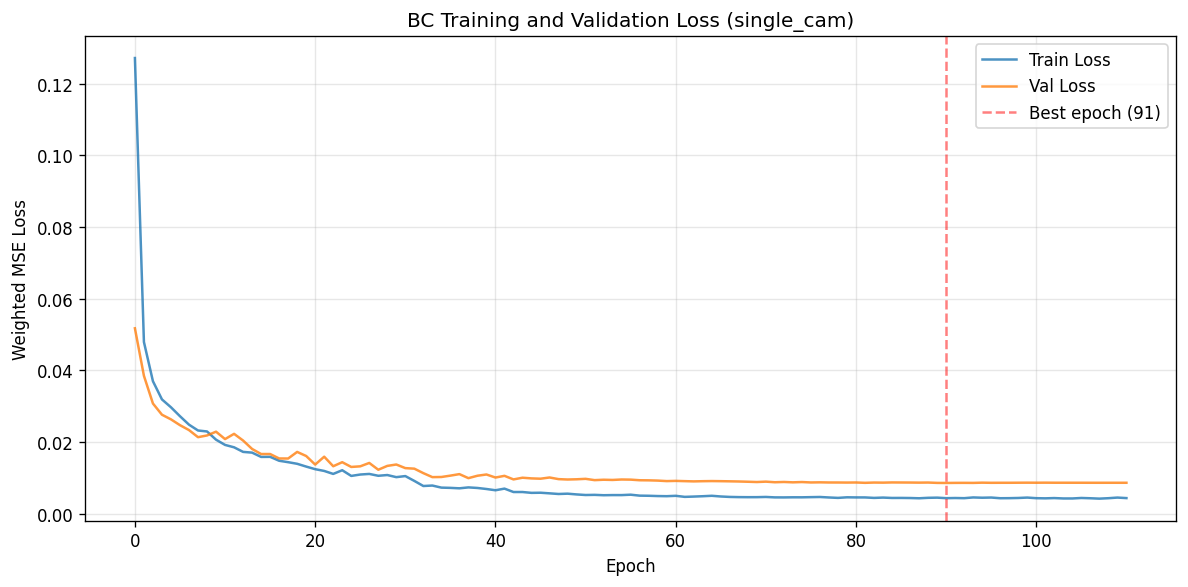

Best epoch: 91
Best val loss: 0.008557
Epochs trained: 111


In [9]:
history_path = RESULTS_DIR / f"bc_training_history_{SENSOR_SUITE}.json"
with open(history_path, "r") as f:
    history = json.load(f)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train_losses"], label="Train Loss", alpha=0.8)
ax.plot(history["val_losses"], label="Val Loss", alpha=0.8)
ax.axvline(
    history["best_epoch"] - 1, color="red", linestyle="--", alpha=0.5,
    label=f"Best epoch ({history['best_epoch']})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE Loss")
ax.set_title(f"BC Training and Validation Loss ({SENSOR_SUITE})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best epoch: {history['best_epoch']}")
print(f"Best val loss: {history['best_val_loss']:.6f}")
print(f"Epochs trained: {history['epochs_trained']}")


### 2.5.2 Per-Target MSE

Breaking down the validation loss by target (steer, throttle, brake) reveals whether one action dimension is dominating the total loss or lagging behind. Ideally all three should decrease together. If brake MSE is disproportionately high despite the 5x upweighting, the model may need additional training data with braking events.

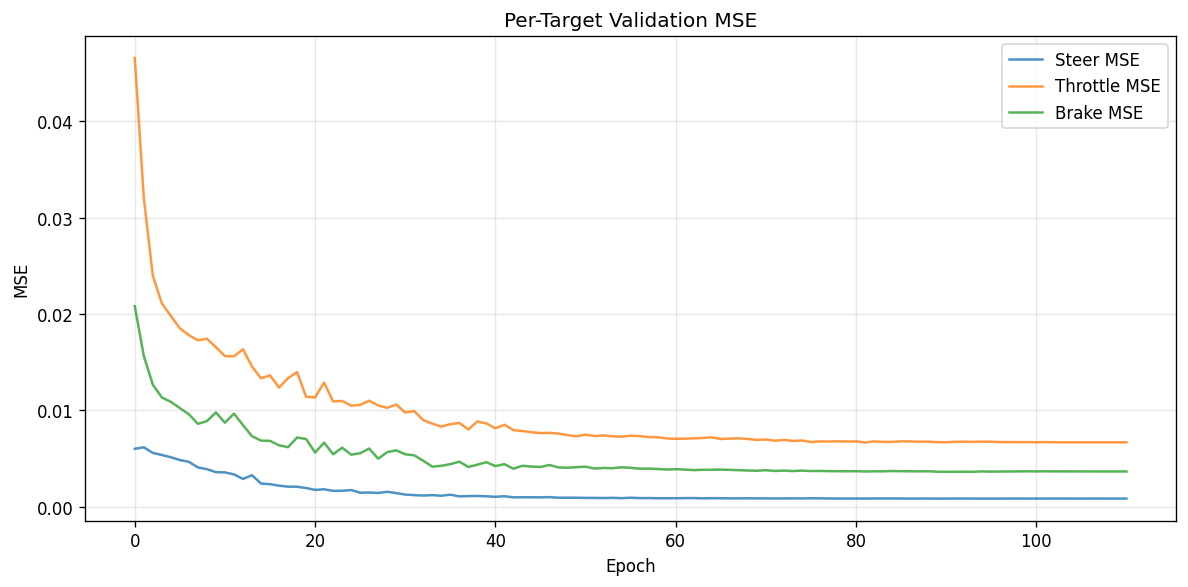

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["val_steer_mse"], label="Steer MSE", alpha=0.8)
ax.plot(history["val_throttle_mse"], label="Throttle MSE", alpha=0.8)
ax.plot(history["val_brake_mse"], label="Brake MSE", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Per-Target Validation MSE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 Evaluation

Final evaluation uses the held-out test set that was not seen during training or validation. We report aggregate metrics and produce scatter plots comparing predicted vs ground truth values for each action dimension. These plots reveal systematic biases (e.g., the model consistently under-predicting braking) that aggregate metrics alone might mask.

### 2.6.1 Test Set Metrics

The test metrics are loaded from the JSON file written by the agent. They include the overall weighted loss and per-target MSE values. These numbers represent the model's performance on conditions it has never seen during training and serve as the baseline for comparison with PPO-finetuned models.

In [11]:
metrics_path = RESULTS_DIR / f"bc_test_metrics_{SENSOR_SUITE}.json"
with open(metrics_path, "r") as f:
    test_metrics = json.load(f)

print(f"=== BC Test Set Metrics ({SENSOR_SUITE}) ===")
for key, value in test_metrics.items():
    if isinstance(value, float):
        print(f"  {key:<20s}: {value:.6f}")
    else:
        print(f"  {key:<20s}: {value}")


=== BC Test Set Metrics (single_cam) ===
  sensor_suite        : single_cam
  test_loss           : 0.007798
  test_steer_mse      : 0.000943
  test_throttle_mse   : 0.006163
  test_brake_mse      : 0.003147


### 2.6.2 Prediction vs Ground Truth Scatter

These scatter plots show model predictions against ground truth for each of the three action dimensions on the test set. Points along the diagonal line indicate perfect predictions. Clouds of points offset from the diagonal reveal systematic biases. Dense clusters near zero on the brake axis are expected given the class imbalance.

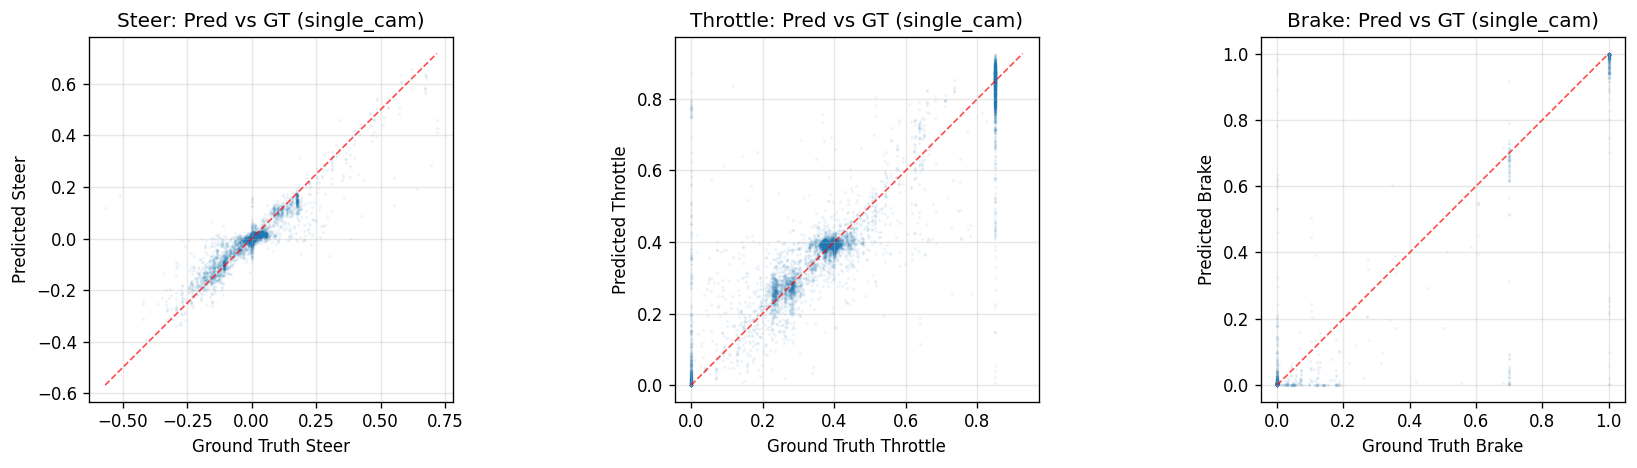

Test samples: 9,795


In [12]:
# Load the best checkpoint -- model class depends on sensor suite
model_kwargs = dict(dropout=cfg["dropout"], state_dim=6, action_dim=3,
                    meta_dims=cfg["meta_dims"])
if SENSOR_SUITE == "single_cam":
    best_model = DriveNet(**model_kwargs).to(device)
elif SENSOR_SUITE == "multi_cam":
    best_model = MultiCamDriveNet(**model_kwargs).to(device)
else:
    best_model = LidarDriveNet(**model_kwargs).to(device)

ckpt_path = MODELS_DIR / f"BC_model_{SENSOR_SUITE}_best.pt"
best_model.load_state_dict(
    torch.load(ckpt_path, map_location=device, weights_only=True))
best_model.eval()

from src.dataset import DrivingDataset
from torch.utils.data import DataLoader

# raw["images"] is already preprocessed and raw["states"] is already normalized
# (both set in the data loading cell above)
split_path = RESULTS_DIR / f"bc_split_indices_{SENSOR_SUITE}.npz"
splits = np.load(split_path)
test_idx = splits["test"]

meta_test = encode_metadata(
    raw, cfg["weather_codes"], cfg["road_type_codes"],
    cfg["tod_codes"], cfg["traffic_codes"], cfg["style_codes"],
)
test_ds = DrivingDataset(raw["images"], raw["states"], raw["actions"],
                         meta_test, test_idx)
test_loader = DataLoader(
    test_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

results = predict_all(best_model, test_loader, device)
preds = results["predictions"]
targets = results["targets"]

action_names = ["Steer", "Throttle", "Brake"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ax, name) in enumerate(zip(axes, action_names)):
    ax.scatter(targets[:, i], preds[:, i], alpha=0.05, s=1, rasterized=True)
    lo = min(targets[:, i].min(), preds[:, i].min())
    hi = max(targets[:, i].max(), preds[:, i].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, alpha=0.7)
    ax.set_xlabel(f"Ground Truth {name}")
    ax.set_ylabel(f"Predicted {name}")
    ax.set_title(f"{name}: Pred vs GT ({SENSOR_SUITE})")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Test samples: {len(targets):,}")


## 2.7 Save

The final section verifies that all expected artifacts were written to disk and saves a snapshot of the BC configuration for reproducibility. The checkpoint file `BC_model_best.pt` is the primary output of this notebook and is used as input for PPO fine-tuning (Notebook 3) and evaluation (Notebook 4).

### 2.7.1 Checkpoint Verification

We confirm that the best-model checkpoint file exists and report its size on disk. A missing or unusually small checkpoint file indicates that training did not complete successfully. The file should typically be 5-15 MB depending on the metadata embedding dimensions.

In [13]:
ckpt_path = MODELS_DIR / f"BC_model_{SENSOR_SUITE}_best.pt"

if ckpt_path.exists():
    size_mb = ckpt_path.stat().st_size / (1024 ** 2)
    print(f"Checkpoint: {ckpt_path}")
    print(f"File size:  {size_mb:.2f} MB")
    state_dict = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    print(f"Keys:       {len(state_dict)} parameter tensors")
    print("Checkpoint verified.")
else:
    print(f"ERROR: Checkpoint not found at {ckpt_path}")

Checkpoint: C:\Users\joshu\Documents\Projects\CARLA AV\models\BC_model_single_cam_best.pt
File size:  6.32 MB
Keys:       33 parameter tensors
Checkpoint verified.


### 2.7.2 Config Snapshot

Saving the exact BC configuration as a JSON snapshot records the hyperparameters used for this training run. Combined with the training history and test metrics JSONs, this provides complete reproducibility information for the behavior cloning stage.

In [14]:
config_snapshot_path = RESULTS_DIR / "bc_config_snapshot.json"
with open(config_snapshot_path, "w") as f:
    json.dump(cfg, f, indent=2, default=str)

print(f"Config snapshot saved to: {config_snapshot_path}")
print(f"Keys: {list(cfg.keys())}")

Config snapshot saved to: C:\Users\joshu\Documents\Projects\CARLA AV\results\bc_config_snapshot.json
Keys: ['seed', 'batch_size', 'lr', 'weight_decay', 'max_epochs', 'early_stop_patience', 'lr_patience', 'lr_factor', 'dropout', 'loss_weights', 'test_fraction', 'val_fraction', 'meta_dims', 'model_name', 'weather_codes', 'road_type_codes', 'tod_codes', 'traffic_codes', 'style_codes']
